# Predicting Credit Default Risk

## 1. Project Overview & Executive Summary
Credit risk assessment is a critical function for financial institutions. The ability to accurately predict whether a borrower will default on a loan directly impacts profitability and lending strategy. 

**Objective:** The primary goal of this project is to build a robust machine learning classification model to predict credit default risk. By analyzing historical loan applications, borrower characteristics, and credit inquiry data, this model will identify high-risk applicants and provide actionable insights for credit-risk decision-making.

**The Prediction Target:** We define default as a binary outcome:
* `target_default = 1` (Applicant defaulted / "Charged Off")
* `target_default = 0` (Applicant did not default)

**Datasets Used:**
1. **Applications Data:** Contains borrower profiles, loan details, and final outcomes.
2. **Inquiries Data:** Contains supplementary credit inquiry information.

---
## 2. Initial Data Loading & Inspection
Before applying any transformations, we will load the raw datasets and perform an initial profile to understand their structure, data types, and identify any immediate data quality issues (missing values, incorrect formatting, etc.).

In [2]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# loading the datasets into a pandas dataframe

cr_applications_df=pd.read_csv('datasets/creditrisk_applications_final.csv')
cr_inquiries_df=pd.read_csv('datasets/creditrisk_inquiries_final.csv')

In [10]:
print("="*50)
print("APPLICATIONS DATA: FIRST 5 ROWS")
print("="*50)
cr_applications_df.head()

APPLICATIONS DATA: FIRST 5 ROWS


,application_id,requested_amount_usd,repayment_term_text,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,risk_grade_band,risk_grade_detail,employment_tenure_text,housing_status,...,origination_month,outcome_status,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text
0,41080563,18000.0,60 months,13.33,412.61,15325.62,C,C3,3 years,OWN,...,Feb-2015,Fully Paid,debt_consolidation,AZ,6.78,670.0,674.0,7.0,0.0,89.5
1,76295652,1000.0,36 months,11.99,33.21,842.45,C,C1,1 year,RENT,...,Apr-2016,Fully Paid,home_improvement,FL,11.54,690.0,694.0,3.0,1.0,13.3
2,60586596,21275.0,36 months,10.99,696.42,7380.80,B,B4,5 years,MORTGAGE,...,Sep-2015,Fully Paid,debt_consolidation,PA,23.08,680.0,684.0,13.0,0.0,75.7
3,59310389,35000.0,60 months,16.99,869.66,32305.48,D,D3,10+ years,MORTGAGE,...,Sep-2015,Fully Paid,credit_card,SC,16.3,710.0,714.0,10.0,0.0,76.5
4,44516103,17000.0,60 months,17.57,427.73,427.73,D,D4,8 years,RENT,...,Apr-2015,Charged Off,credit_card,CA,31.27,680.0,684.0,8.0,0.0,62.5


In [11]:
print("="*50)
print("INQUIRIES DATA: FIRST 5 ROWS")
print("="*50)
cr_applications_df.head()
cr_inquiries_df.head()

INQUIRIES DATA: FIRST 5 ROWS


,requested_amount_usd,application_date,request_title,screening_score,debt_to_income_text,region_code,employment_tenure_text,policy_code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,MD,< 1 year,0.0


In [ ]:
# Exploring the data shapes

print("="*50)
print("DATASET SHAPES")
print("="*50)
print(f"Applications Data: {cr_applications_df.shape[0]} rows, {cr_applications_df.shape[1]} columns")
print(f"Inquiries Data:    {cr_inquiries_df.shape[0]} rows, {cr_inquiries_df.shape[1]} columns\n")

DATASET SHAPES
Applications Data: 85000 rows, 22 columns
Inquiries Data:    45000 rows, 8 columns



In [14]:
print("="*50)
print("APPLICATIONS DATA: INFO & DATA TYPES")
print("="*50)
cr_applications_df.info()
print("\n")

APPLICATIONS DATA: INFO & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   application_id              85000 non-null  int64  
 1   requested_amount_usd        85000 non-null  float64
 2   repayment_term_text         85000 non-null  object 
 3   interest_rate_text          85000 non-null  float64
 4   monthly_installment_usd     85000 non-null  float64
 5   last_payment_amount_usd     85000 non-null  float64
 6   risk_grade_band             85000 non-null  object 
 7   risk_grade_detail           85000 non-null  object 
 8   employment_tenure_text      76324 non-null  object 
 9   housing_status              85000 non-null  object 
 10  annual_income_usd           84320 non-null  float64
 11  income_verification_status  85000 non-null  object 
 12  origination_month           85000 non-null  object 

In [15]:
print("="*50)
print("INQUIRIES DATA: INFO & DATA TYPES")
print("="*50)
cr_inquiries_df.info()
print("\n")

INQUIRIES DATA: INFO & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   requested_amount_usd    45000 non-null  float64
 1   application_date        45000 non-null  object 
 2   request_title           44991 non-null  object 
 3   screening_score         40476 non-null  float64
 4   debt_to_income_text     45000 non-null  object 
 5   region_code             44979 non-null  object 
 6   employment_tenure_text  44998 non-null  object 
 7   policy_code             45000 non-null  float64
dtypes: float64(3), object(5)
memory usage: 2.7+ MB




In [7]:
# Missing Values Check
print("="*50)
print("MISSING VALUES SUMMARY")
print("="*50)
print("Applications Data (Missing > 0):")
app_missing = cr_applications_df.isnull().sum()
print(app_missing[app_missing > 0].sort_values(ascending=False))


print("\nInquiries Data (Missing > 0):")
inq_missing = cr_inquiries_df.isnull().sum()
print(inq_missing[inq_missing > 0].sort_values(ascending=False))
print("\n")

MISSING VALUES SUMMARY
Applications Data (Missing > 0):
employment_tenure_text        8676
revolving_utilization_text     892
debt_to_income_ratio           709
annual_income_usd              680
dtype: int64

Inquiries Data (Missing > 0):
screening_score           4524
region_code                 21
request_title                9
employment_tenure_text       2
dtype: int64




In [20]:
# duplicated row Check
print("="*50)
print("DUPLICATED ROWS SUMMARY")
print("="*50)
print("Applications Data (Duplicated > 0):")
app_duplicates = cr_applications_df.duplicated(keep='first').sum()
print(f"Number of duplicated rows in Applications Data: {app_duplicates}")

print("\nInquiries Data (Duplicated > 0):")
inq_duplicates = cr_inquiries_df.duplicated(keep='first').sum()
print(f"Number of duplicated rows in Inquiries Data: {inq_duplicates}")
print("\n")


DUPLICATED ROWS SUMMARY
Applications Data (Duplicated > 0):
Number of duplicated rows in Applications Data: 0

Inquiries Data (Duplicated > 0):
Number of duplicated rows in Inquiries Data: 15




In [ ]:
# Statistical Summary
print("="*50)
print("APPLICATIONS DATA: STATISTICAL SUMMARY (NUMERICAL)")
print("="*50)
display(cr_applications_df.describe())

APPLICATIONS DATA: STATISTICAL SUMMARY (NUMERICAL)


,application_id,requested_amount_usd,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,annual_income_usd,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text
count,8.500000e+04,85000.000000,85000.000000,85000.000000,85000.000000,8.432000e+04,85000.000000,85000.000000,85000.000000,85000.000000,84108.000000
mean,6.633685e+07,14950.852647,13.600630,446.071413,3604.090989,7.434189e+04,692.034412,696.034482,11.920871,0.248718,52.342891
std,2.482399e+07,8735.147461,4.886372,258.523612,6222.901104,7.732271e+04,29.787475,29.787839,5.670095,0.656437,24.293508
min,3.476740e+05,1000.000000,5.310000,30.120000,0.000000,0.000000e+00,660.000000,664.000000,1.000000,0.000000,0.000000
25%,4.881616e+07,8000.000000,9.990000,259.955000,308.220000,4.500000e+04,670.000000,674.000000,8.000000,0.000000,34.200000
50%,6.059760e+07,13050.000000,13.180000,382.870000,598.895000,6.300000e+04,685.000000,689.000000,11.000000,0.000000,52.800000
75%,7.635120e+07,20000.000000,16.550000,587.690000,4130.377500,9.000000e+04,705.000000,709.000000,15.000000,0.000000,70.900000
max,1.411120e+08,40000.000000,30.990000,1587.230000,40551.270000,8.900060e+06,845.000000,850.000000,70.000000,49.000000,136.400000


In [18]:
# Statistical Summary
print("="*50)
print("INQUIRIES DATA: STATISTICAL SUMMARY (NUMERICAL)")
print("="*50)
display(cr_inquiries_df.describe())

INQUIRIES DATA: STATISTICAL SUMMARY (NUMERICAL)


,requested_amount_usd,screening_score,policy_code
count,45000.000000,40476.000000,45000.0
mean,9039.969925,574.065743,0.0
std,6902.052667,154.736712,0.0
min,500.000000,0.000000,0.0
25%,3500.000000,513.000000,0.0
50%,7000.000000,609.000000,0.0
75%,14000.000000,670.000000,0.0
max,40000.000000,828.000000,0.0


## 3. Comprehensive Data Cleaning & Transformation

To ensure a robust foundation for modeling, the dataset requires structural cleaning, deduplication, and handling of missing values. We apply transformations to independent copies of the raw data (`cr_app_clean_df` and `cr_inq_clean_df`).

In [56]:
# Create Working Copies for cleaning and Transformation.
cr_app_clean_df = cr_applications_df.copy()
cr_inq_clean_df = cr_inquiries_df.copy()

**Application Data Cleaning**

In [60]:
# Deduplication
# Only the Inquiries dataset has duplicates, so we will deduplicate the dataset.

cr_inq_clean_df.drop_duplicates(keep='first', inplace=True)

# Target Variable Encoding.
# Generated here to allow for bivariate analysis during EDA
cr_app_clean_df['target_default'] = np.where(cr_app_clean_df['outcome_status'] == 'Charged Off', 1, 0)

# String Cleaning & Formatting - Loan Purpose happens to have leading/trailing spaces, so we will clean it.
cr_app_clean_df['loan_purpose'] = cr_app_clean_df['loan_purpose'].astype(str).str.strip()

# Date Formatting
cr_app_clean_df['origination_month'] = pd.to_datetime(cr_app_clean_df['origination_month'], format='%b-%Y', errors='coerce')

# Text-to-Numeric Parsing 
# Applications Data
cr_app_clean_df['repayment_term_months'] = cr_app_clean_df['repayment_term_text'].astype(str).str.replace(' months', '', regex=False).str.strip().astype(float)
cr_app_clean_df['interest_rate'] = cr_app_clean_df['interest_rate_text'].astype(str).str.strip().astype(float)
cr_app_clean_df['revolving_utilization'] = cr_app_clean_df['revolving_utilization_text'].astype(str).str.replace('%', '', regex=False).str.strip().astype(float)
cr_app_clean_df['employment_tenure_years'] = cr_app_clean_df['employment_tenure_text'].astype(str).str.extract(r'(\d+)').astype(float)

cr_app_clean_df['debt_to_income_ratio'] = (
    pd.to_numeric(
        cr_app_clean_df['debt_to_income_ratio'].astype(str).str.strip(),
        errors='coerce'
    )
)

# # Correcting Datatypes (Counts to Int)
# cr_app_clean_df['open_credit_lines'] = cr_app_clean_df['open_credit_lines'].astype(int)
# cr_app_clean_df['public_records_count'] = cr_app_clean_df['public_records_count'].astype(int)

In [63]:
# Missing Value Imputation

# Numerical: Median Imputation
app_num_cols = ['employment_tenure_years', 'revolving_utilization', 'debt_to_income_ratio', 'annual_income_usd']
for col in app_num_cols:
    cr_app_clean_df[col] = cr_app_clean_df[col].fillna(cr_app_clean_df[col].median())

In [64]:
# Drop Redundant Raw Text Columns
cols_to_drop_apps = ['repayment_term_text', 'interest_rate_text', 'revolving_utilization_text', 'employment_tenure_text']
cr_app_clean_df.drop(columns=[col for col in cols_to_drop_apps if col in cr_app_clean_df.columns], inplace=True)


**Inquiries Data Cleaning**


In [65]:
# Inquiries Data
cr_inq_clean_df['employment_tenure_years'] = cr_inq_clean_df['employment_tenure_text'].astype(str).str.extract(r'(\d+)').astype(float)
cr_inq_clean_df['debt_to_income'] = cr_inq_clean_df['debt_to_income_text'].astype(str).str.replace('%', '', regex=False).str.strip().astype(float)

# Date Formatting
cr_inq_clean_df['application_date'] = pd.to_datetime(cr_inq_clean_df['application_date'], errors='coerce')

In [66]:
# Missing Value Imputation

# Numerical: Median Imputation
inq_num_cols = ['screening_score', 'employment_tenure_years', 'debt_to_income']
for col in inq_num_cols:
    cr_inq_clean_df[col] = cr_inq_clean_df[col].fillna(cr_inq_clean_df[col].median())

# Categorical: Mode and Unknown Imputation
cr_inq_clean_df['region_code'] = cr_inq_clean_df['region_code'].fillna(cr_inq_clean_df['region_code'].mode()[0])
cr_inq_clean_df['request_title'] = cr_inq_clean_df['request_title'].fillna('Unknown')

In [67]:
# Drop Redundant Raw Text Columns

cr_inq_clean_df.drop(columns=['debt_to_income_text', 'employment_tenure_text'], inplace=True, errors='ignore')

In [72]:
# Final Quality Check
print("="*50)
print("CLEANING COMPLETE: MISSING VALUES REMAINING")
print("="*50)
print(f"Applications Dataset: {cr_app_clean_df.isnull().sum().sum()} missing values")
print(f"Inquiries Dataset:    {cr_inq_clean_df.isnull().sum().sum()} missing values")

print("\n" + "="*50)
print("NEW DATA TYPES (APPLICATIONS SNAPSHOT)")
print("="*50)
print(cr_app_clean_df[['origination_month', 'debt_to_income_ratio', 'repayment_term_months', 'target_default']].dtypes)


CLEANING COMPLETE: MISSING VALUES REMAINING
Applications Dataset: 0 missing values
Inquiries Dataset:    0 missing values

NEW DATA TYPES (APPLICATIONS SNAPSHOT)
origination_month        datetime64[ns]
debt_to_income_ratio            float64
repayment_term_months           float64
target_default                    int64
dtype: object


**Transformation & Integrity Measures:**

1. **Target Variable Optimization:** The binary classification target `target_default` is encoded immediately from `outcome_status` to facilitate bivariate tracking and segmentation during Exploratory Data Analysis (EDA).

2. **Text-to-Numeric Conversion**: Raw string fields (like " 36 months", "13.33", and "89.5%") are parsed into standard floating-point numbers.

3. **Robust Text Parsing**: We use pd.to_numeric(errors='coerce') on financial metrics. This safely converts format anomalies into missing values (NaN) instead of crashing the script.

4. **Data-Driven Missing Value Imputation:** - **Numerical Scale Fields:** Missing values and coerced fields are safely resolved via median imputation, ensuring that localized missingness does not distort overall data distribution shapes or central tendencies.
   - **Categorical Columns:** Missing values in critical categories are handled using the statistical mode or flagged with an explicit `"Unknown"` marker to preserve structural group history.

5. **Categorical Columns**: Missing values are filled using the most frequent group (mode) or labeled as "Unknown".

6. **Outlier Preservation**: Extreme values in the debt-to-income ratio are intentionally left uncapped. In credit risk, a massive debt load often points to high real-world risk rather than a system glitch; keeping them preserves vital patterns.

6. **String & Date Standardization:** Whitespace is systematically stripped from categorical arrays like `loan_purpose`, and chronological data fields are shifted to datetime formats.

## Data Cleaning and Target Definition

## Expolratory Data Analysis

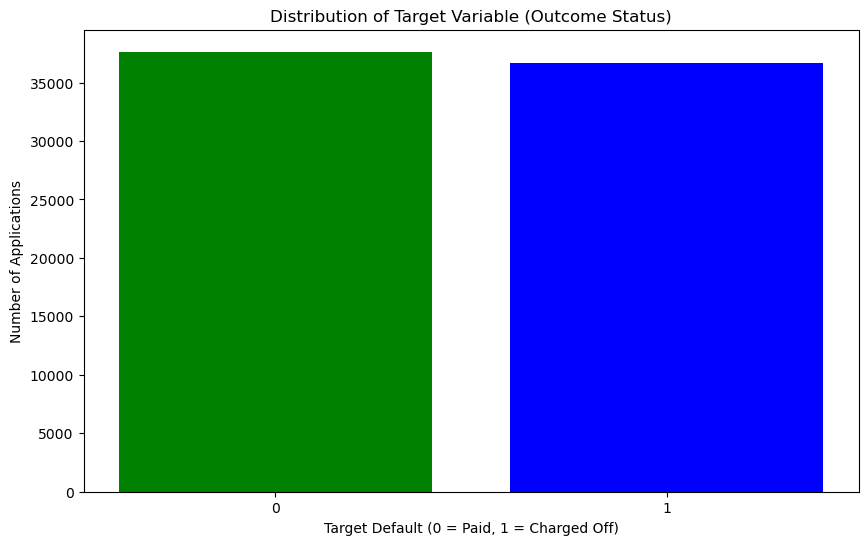

target_default
0    50.65538
1    49.34462
Name: proportion, dtype: float64


In [43]:
# Bar Chart Distribution between people who refunded the loan in full and defaulters
target_counts = df_cleaned['target_default'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(target_counts.index.astype(str), target_counts.values, color=['green', 'blue'])
plt.title('Distribution of Target Variable (Outcome Status)')
plt.xlabel('Target Default (0 = Paid, 1 = Charged Off)')
plt.ylabel('Number of Applications')
plt.show()

print(df_cleaned['target_default'].value_counts(normalize=True) * 100)

/var/folders/_r/yhvx8n417sn7rzmjkkjyhnkr0000gn/T/ipykernel_35657/142969024.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_grade = df_cleaned.groupby('risk_grade_band')['target_default'].mean().reset_index()


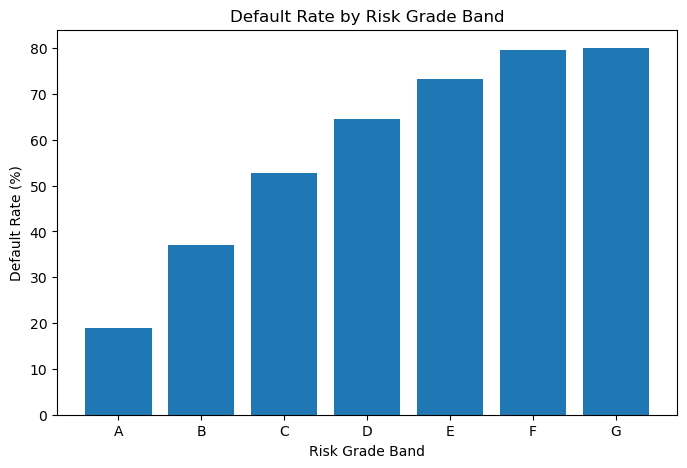

  risk_grade_band  target_default  default_rate(%)
0               A        0.189814        18.981437
1               B        0.371181        37.118140
2               C        0.528501        52.850096
3               D        0.644945        64.494505
4               E        0.732177        73.217700
5               F        0.796464        79.646382
6               G        0.800241        80.024067


In [44]:
# BarChart to display the categories of Risk Grade Band by Defaulters' Rate
risk_grade = df_cleaned.groupby('risk_grade_band')['target_default'].mean().reset_index()
risk_grade['default_rate(%)'] = risk_grade['target_default'] * 100

plt.figure(figsize=(8, 5))
plt.bar(risk_grade['risk_grade_band'], risk_grade['default_rate(%)'])
plt.title('Default Rate by Risk Grade Band')
plt.xlabel('Risk Grade Band')
plt.ylabel('Default Rate (%)')
plt.show()

print(risk_grade)


/var/folders/_r/yhvx8n417sn7rzmjkkjyhnkr0000gn/T/ipykernel_33171/4044640143.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purpose = df_cleaned.groupby('loan_purpose')['target_default'].mean().reset_index()


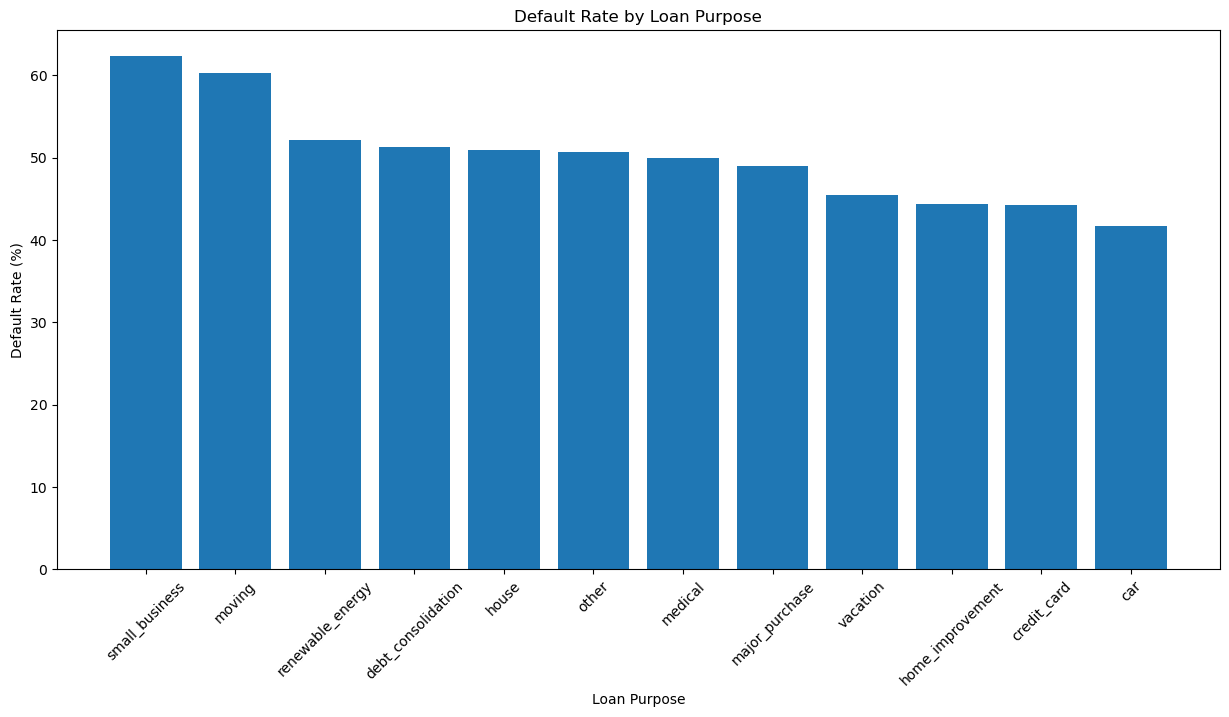

          loan_purpose  target_default  purpose(%)
10      small_business        0.623865   62.386511
7               moving        0.603232   60.323160
9     renewable_energy        0.521739   52.173913
2   debt_consolidation        0.513049   51.304931
4                house        0.509749   50.974930
8                other        0.506344   50.634427
6              medical        0.499376   49.937578
5       major_purchase        0.489477   48.947726
11            vacation        0.454167   45.416667
3     home_improvement        0.443908   44.390779
1          credit_card        0.442317   44.231748
0                  car        0.416923   41.692308


In [ ]:
# BarChart to display the categories of Risk Grade Band by Defaulters' Rate
purpose = df_cleaned.groupby('loan_purpose')['target_default'].mean().reset_index()
purpose['purpose(%)'] = purpose['target_default'] * 100

purpose = purpose.sort_values(by='purpose(%)', ascending=False)

plt.figure(figsize=(15, 7))
plt.bar(purpose['loan_purpose'], purpose['purpose(%)'])
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()

print(purpose)


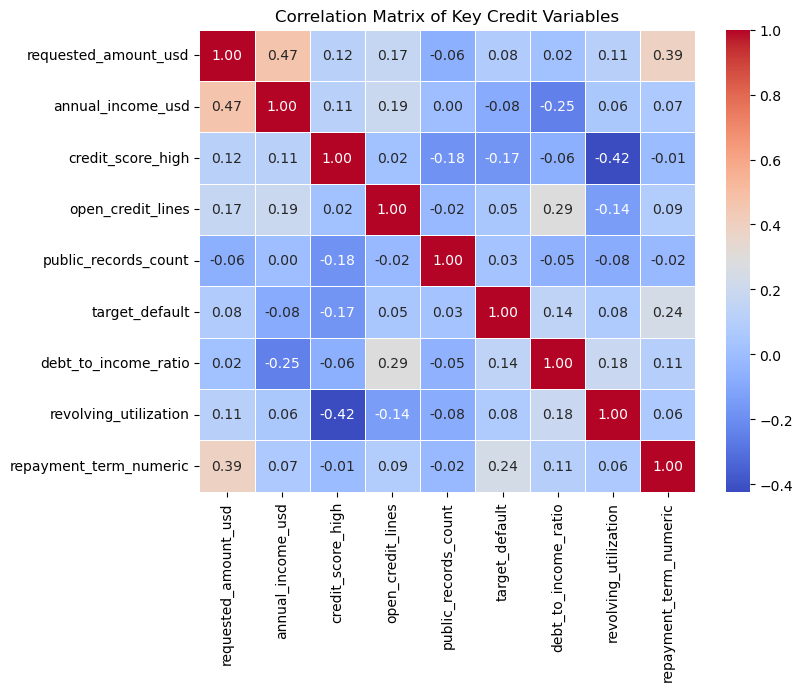

In [53]:
import seaborn as sns

numeric_cols = ['requested_amount_usd', 'annual_income_usd', 'credit_score_high', 
                'open_credit_lines', 'public_records_count', 'target_default', 'debt_to_income_ratio', 'revolving_utilization', 'repayment_term_numeric']

corr_matrix = df_cleaned[numeric_cols].corr()

# Visualize the correlation matrix with a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Credit Variables')
plt.show()

### Summary

- Approximately 49% of the applicants are loan defaulters, while approximately 51% paid back in full. 
- Credit scores are clustered tightly between 660 and 850, with an average of around 692, suggesting that only applicants with good credit score were considered for the loan. so credit score alone may not separate defaulters from non-defaulters very well within this group. 
- Annual income ranged from $100 to $250,000, but the average ($74,600) sits above the median ($65,000), meaning a smaller number of high earners are pulling the mean up.
- Revolving credit utilization has an avergage of 52.6%, which means the typical borrower was using more than half their available credit. 
- The debt-to-income ratio ranged from 0% to 39%, with most borrowers falling between 13% and 26%. Repayment term has only two values, 36 and 60 months.
- The risk grade band shows that Borrowers in grade A defaulted only 19% of the time, while those in grades F and G defaulted at around 80%. This help prove that borrowers at the lower grade(F and G) are at higher risk of defaulting.
- Small business and moving loans had the highest default rates at around 62% and 60% respectively, while car loans had the lowest at roughly 42%. Other purposes are clustered between 44% and 52%, which is tight. The differences across purposes are present but not much for most categories, which suggests that loan purpose alone is not a strong standalone predictor.
- The correlation matrix shows that credit score has the strongest negative relationship with target_default (−0.17), meaning the higher the credit score the lesser the chances of defaulting. Revolving utilisation (0.08) and debt to income ratio (0.14) both show a small positive relationship with target_default, meaning higher values are associated with slightly more defaults. Repayment term has a correlation of 0.24 with default, suggesting that borrowers bwho are on longer repayment plan are more likely to default compared to their counterpart.

In [1]:
print('Hello')

Hello
